# Employee Burnout Analysis



## 1. Load Data
Load the train and test CSV files.

In [2]:
import pandas as pd

train = pd.read_csv("/content/train.csv")
test = pd.read_csv("/content/test.csv")

## 2. Data Cleaning

In [3]:
train.head()

,Employee ID,Date of Joining,Gender,Company Type,WFH Setup Available,Designation,Resource Allocation,Mental Fatigue Score,Burn Rate
0,fffe32003000360033003200,2008-09-30,Female,Service,No,2.0,3.0,3.8,0.16
1,fffe3700360033003500,2008-11-30,Male,Service,Yes,1.0,2.0,5.0,0.36
2,fffe31003300320037003900,2008-03-10,Female,Product,Yes,2.0,NaN,5.8,0.49
3,fffe32003400380032003900,2008-11-03,Male,Service,Yes,1.0,1.0,2.6,0.20
4,fffe31003900340031003600,2008-07-24,Female,Service,No,3.0,7.0,6.9,0.52


In [4]:
train.shape

(22750, 9)

In [5]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22750 entries, 0 to 22749
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Employee ID           22750 non-null  object 
 1   Date of Joining       22750 non-null  object 
 2   Gender                22750 non-null  object 
 3   Company Type          22750 non-null  object 
 4   WFH Setup Available   22750 non-null  object 
 5   Designation           22750 non-null  float64
 6   Resource Allocation   21369 non-null  float64
 7   Mental Fatigue Score  20633 non-null  float64
 8   Burn Rate             21626 non-null  float64
dtypes: float64(4), object(5)
memory usage: 1.6+ MB


In [6]:
train.describe()

,Designation,Resource Allocation,Mental Fatigue Score,Burn Rate
count,22750.000000,21369.000000,20633.000000,21626.000000
mean,2.178725,4.481398,5.728188,0.452005
std,1.135145,2.047211,1.920839,0.198226
min,0.000000,1.000000,0.000000,0.000000
25%,1.000000,3.000000,4.600000,0.310000
50%,2.000000,4.000000,5.900000,0.450000
75%,3.000000,6.000000,7.100000,0.590000
max,5.000000,10.000000,10.000000,1.000000


### Check Missing Values
Display the count of missing values per column, sorted in descending order.

In [7]:
train.isnull().sum().sort_values(ascending=False)


,0
Mental Fatigue Score,2117
Resource Allocation,1381
Burn Rate,1124
Employee ID,0
Date of Joining,0
WFH Setup Available,0
Company Type,0
Gender,0
Designation,0


## 3. Handle Missing Values
Fill missing values in `Resource Allocation` and `Mental Fatigue Score` with the median, and drop rows where `Burn Rate` (the target column) is missing.

In [8]:
train["Resource Allocation"] = train["Resource Allocation"].fillna(
    train["Resource Allocation"].median()
)

In [9]:
train["Mental Fatigue Score"] = train["Mental Fatigue Score"].fillna(
    train["Mental Fatigue Score"].median()
)

In [10]:
train.dropna(subset=["Burn Rate"], inplace=True)

Confirm that all missing values have been handled.

In [11]:
train.isnull().sum()

,0
Employee ID,0
Date of Joining,0
Gender,0
Company Type,0
WFH Setup Available,0
Designation,0
Resource Allocation,0
Mental Fatigue Score,0
Burn Rate,0


## 4. Handle Duplicates
Check for duplicate rows and remove them.

In [12]:
train.duplicated().sum()


np.int64(0)

In [13]:
train.drop_duplicates(inplace=True)

## 5. Feature Engineering
Inspect the text (object) columns, and extract useful information from the `Date of Joining` column.

In [14]:
train.select_dtypes(include='object').columns

Index(['Employee ID', 'Date of Joining', 'Gender', 'Company Type',
       'WFH Setup Available'],
      dtype='object')

Check the data types again.

In [15]:
train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 21626 entries, 0 to 22749
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Employee ID           21626 non-null  object 
 1   Date of Joining       21626 non-null  object 
 2   Gender                21626 non-null  object 
 3   Company Type          21626 non-null  object 
 4   WFH Setup Available   21626 non-null  object 
 5   Designation           21626 non-null  float64
 6   Resource Allocation   21626 non-null  float64
 7   Mental Fatigue Score  21626 non-null  float64
 8   Burn Rate             21626 non-null  float64
dtypes: float64(4), object(5)
memory usage: 1.6+ MB


Drop the `Employee ID` column since it's just an identifier with no predictive value.

In [16]:
train.drop("Employee ID", axis=1, inplace=True)

Convert the `Date of Joining` column to datetime type.

In [17]:
train["Date of Joining"] = pd.to_datetime(train["Date of Joining"])

Extract the year, month, and day from the joining date as separate columns.

In [18]:
train["Joining_Year"] = train["Date of Joining"].dt.year
train["Joining_Month"] = train["Date of Joining"].dt.month
train["Joining_Day"] = train["Date of Joining"].dt.day

Then drop the original date column since the useful information has already been extracted.

In [19]:
train.drop("Date of Joining", axis=1, inplace=True)

## 6. Encoding
Check the remaining text columns and convert them to numeric using One-Hot Encoding.

In [20]:
train.select_dtypes(include="object").columns

Index(['Gender', 'Company Type', 'WFH Setup Available'], dtype='object')

Apply `pd.get_dummies` with `drop_first=True` to avoid multicollinearity.

In [21]:
train = pd.get_dummies(train, drop_first=True)

Finally, display the shape of the data after all the cleaning and encoding steps.

In [22]:
train.head()

,Designation,Resource Allocation,Mental Fatigue Score,Burn Rate,Joining_Year,Joining_Month,Joining_Day,Gender_Male,Company Type_Service,WFH Setup Available_Yes
0,2.0,3.0,3.8,0.16,2008,9,30,False,True,False
1,1.0,2.0,5.0,0.36,2008,11,30,True,True,True
2,2.0,4.0,5.8,0.49,2008,3,10,False,False,True
3,1.0,1.0,2.6,0.20,2008,11,3,True,True,True
4,3.0,7.0,6.9,0.52,2008,7,24,False,True,False


In [23]:
train.to_csv("cleaned_train.csv", index=False)

EDA


In [30]:
print(train.columns.tolist())

['Designation', 'Resource Allocation', 'Mental Fatigue Score', 'Burn Rate', 'Joining_Year', 'Joining_Month', 'Joining_Day', 'Gender_Male', 'Company Type_Service', 'WFH Setup Available_Yes']


In [38]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8,5)
plt.rcParams["font.size"] = 12

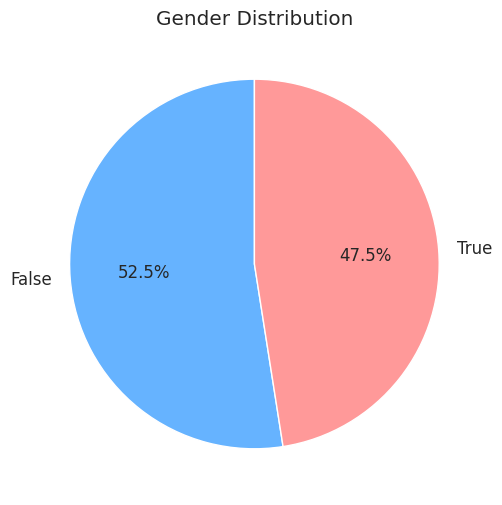

In [40]:
plt.figure(figsize=(6,6))

train.Gender_Male.value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90,
    colors=["#66b3ff","#ff9999"]
)

plt.ylabel("")
plt.title("Gender Distribution")
plt.show()

/tmp/ipykernel_764/2793232378.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=train,x="Company Type_Service",palette="Set2")


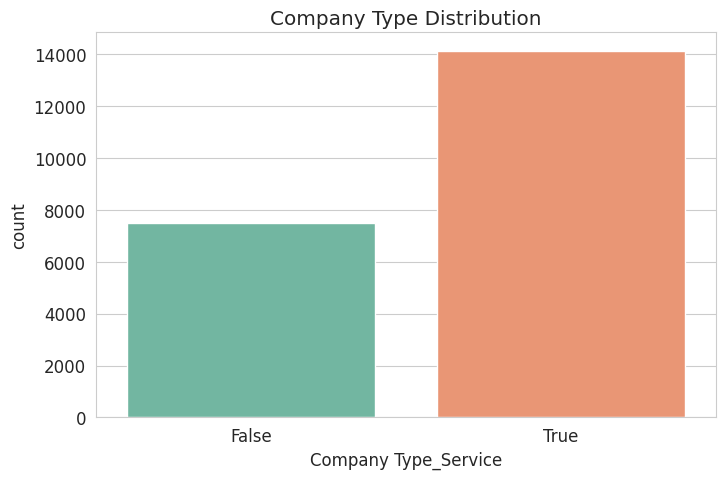

In [43]:
sns.countplot(data=train,x="Company Type_Service",palette="Set2")

plt.title("Company Type Distribution")
plt.show()

/tmp/ipykernel_764/282107589.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=train,x="WFH Setup Available_Yes",palette="Set1")


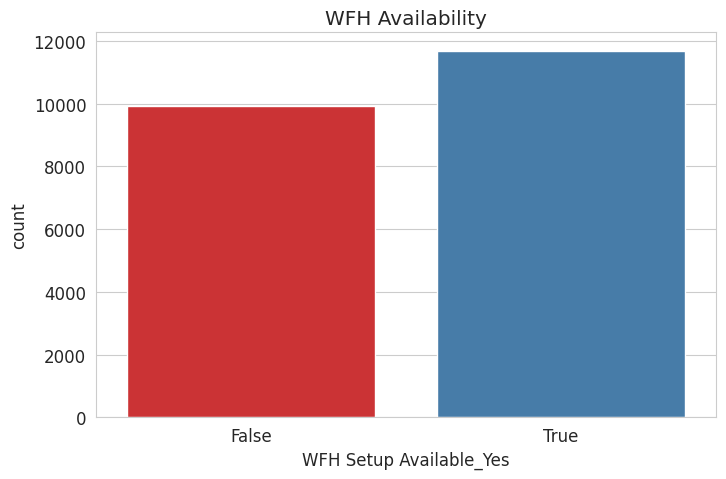

In [45]:
sns.countplot(data=train,x="WFH Setup Available_Yes",palette="Set1")

plt.title("WFH Availability")
plt.show()

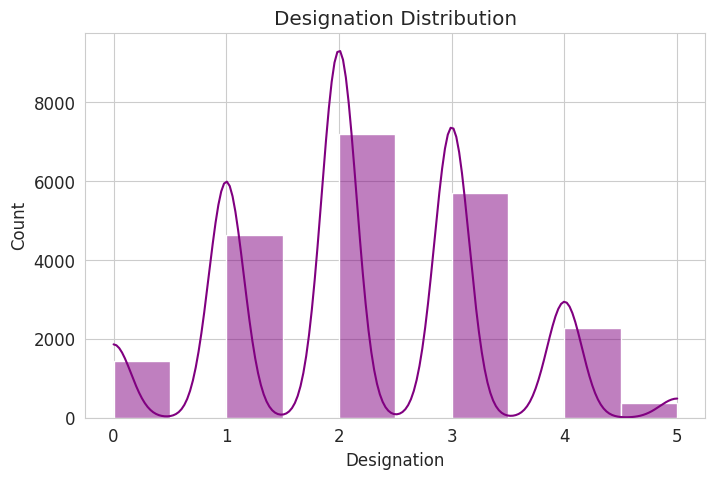

In [46]:
sns.histplot(
    train["Designation"],
    bins=10,
    kde=True,
    color="purple"
)

plt.title("Designation Distribution")
plt.show()

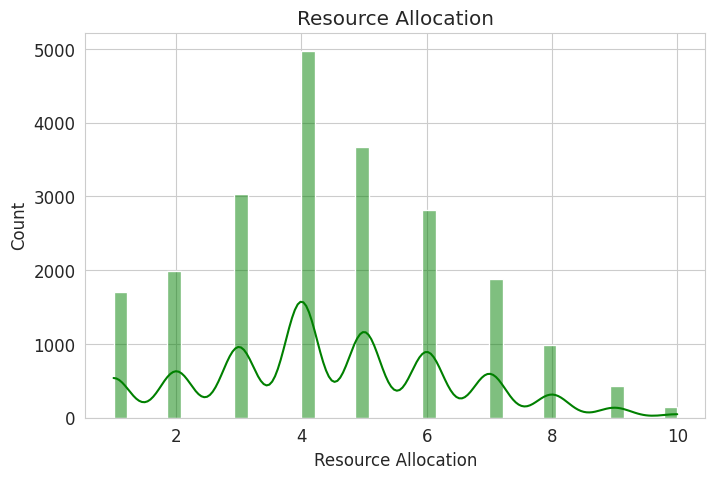

In [47]:
sns.histplot(
    train["Resource Allocation"],
    kde=True,
    color="green"
)

plt.title("Resource Allocation")
plt.show()

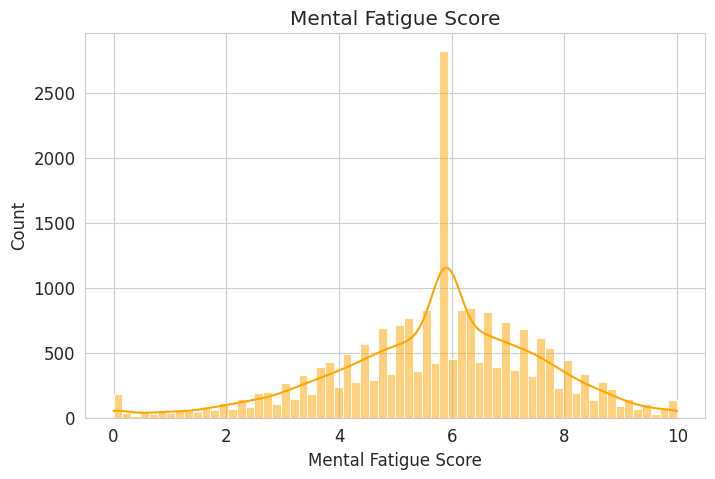

In [48]:
sns.histplot(
    train["Mental Fatigue Score"],
    kde=True,
    color="orange"
)

plt.title("Mental Fatigue Score")
plt.show()

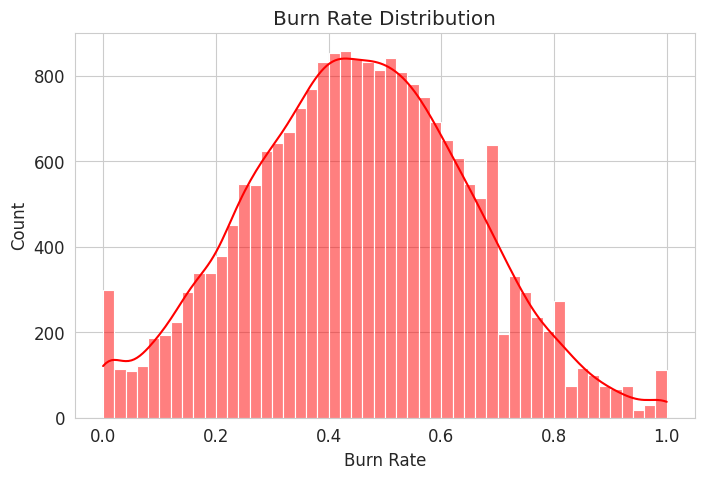

In [49]:
sns.histplot(
    train["Burn Rate"],
    kde=True,
    color="red"
)

plt.title("Burn Rate Distribution")
plt.show()

/tmp/ipykernel_764/534178121.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


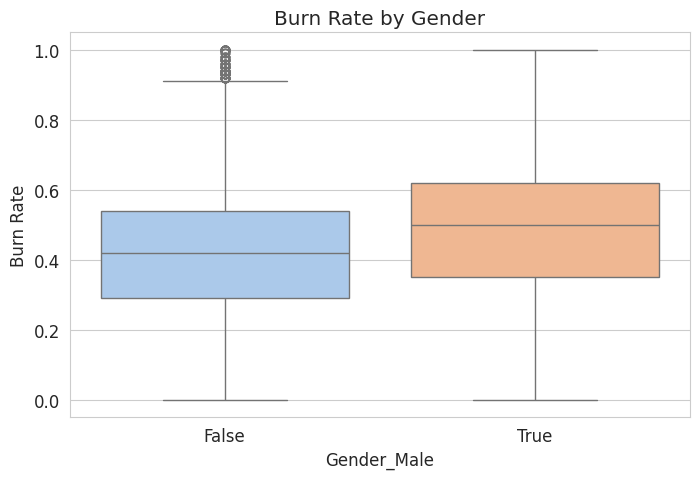

In [51]:
sns.boxplot(
    data=train,
    x="Gender_Male",
    y="Burn Rate",
    palette="pastel"
)

plt.title("Burn Rate by Gender")
plt.show()

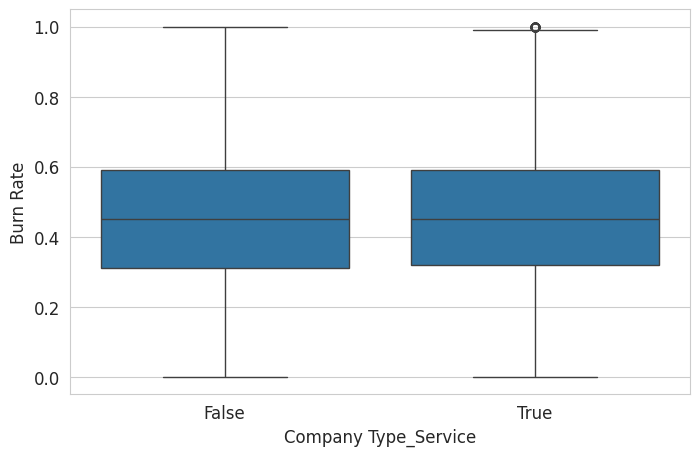

In [53]:
sns.boxplot(
    data=train,
    x="Company Type_Service",
    y="Burn Rate"
)

plt.show()

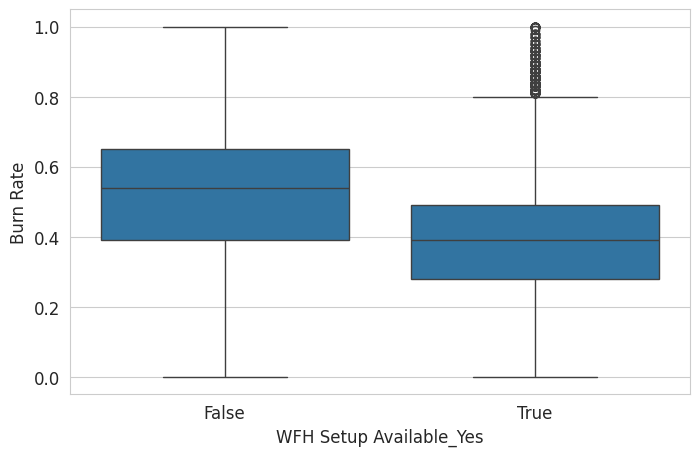

In [55]:
sns.boxplot(
    data=train,
    x="WFH Setup Available_Yes",
    y="Burn Rate"
)

plt.show()

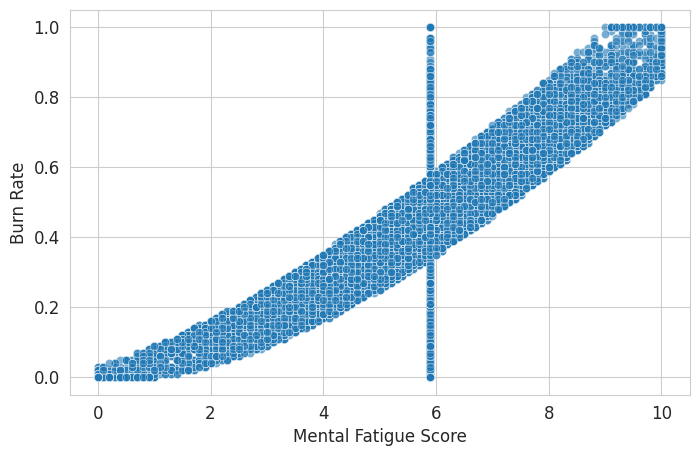

In [56]:
sns.scatterplot(
    data=train,
    x="Mental Fatigue Score",
    y="Burn Rate",
    alpha=0.6
)

plt.show()

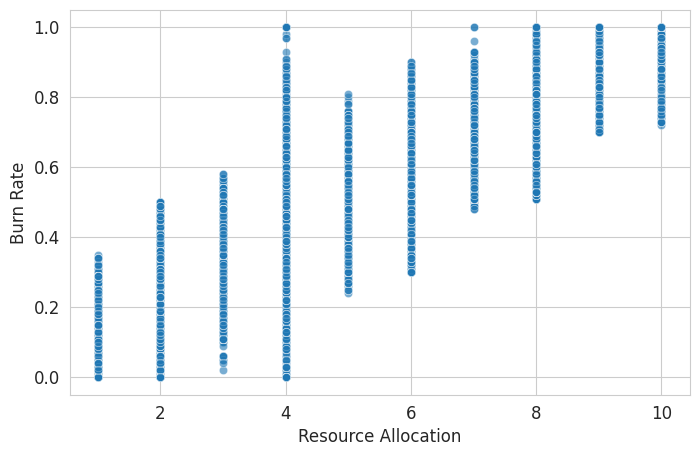

In [57]:
sns.scatterplot(
    data=train,
    x="Resource Allocation",
    y="Burn Rate",
    alpha=0.6
)

plt.show()

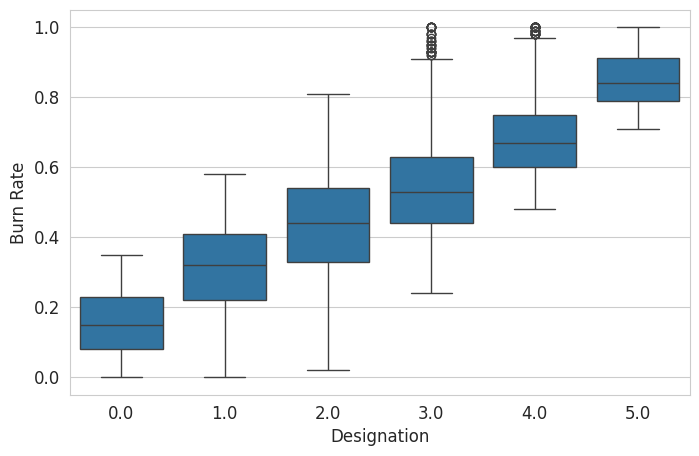

In [58]:
sns.boxplot(
    data=train,
    x="Designation",
    y="Burn Rate"
)

plt.show()

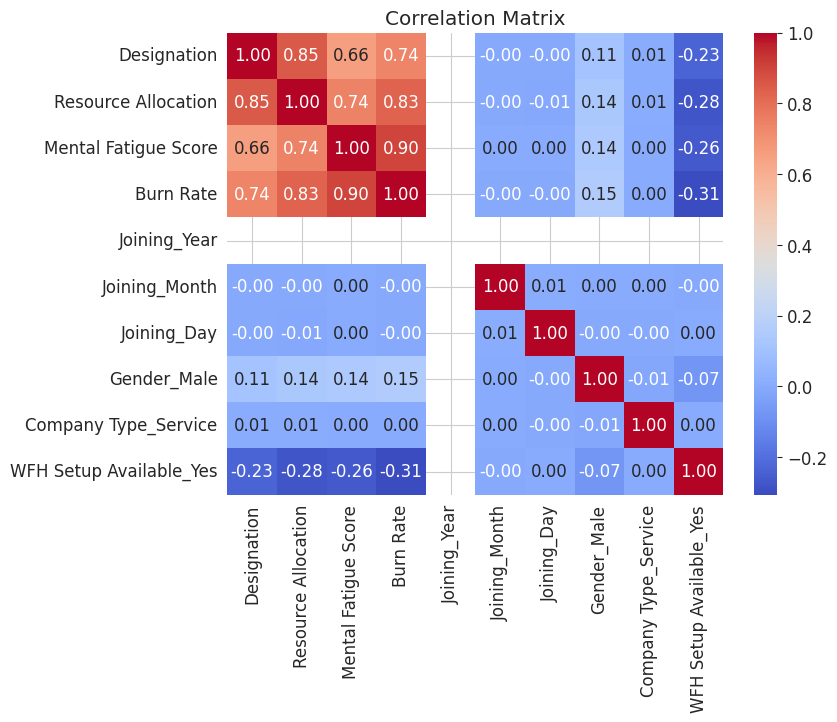

In [59]:
plt.figure(figsize=(8,6))

corr = train.corr(numeric_only=True)

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.show()

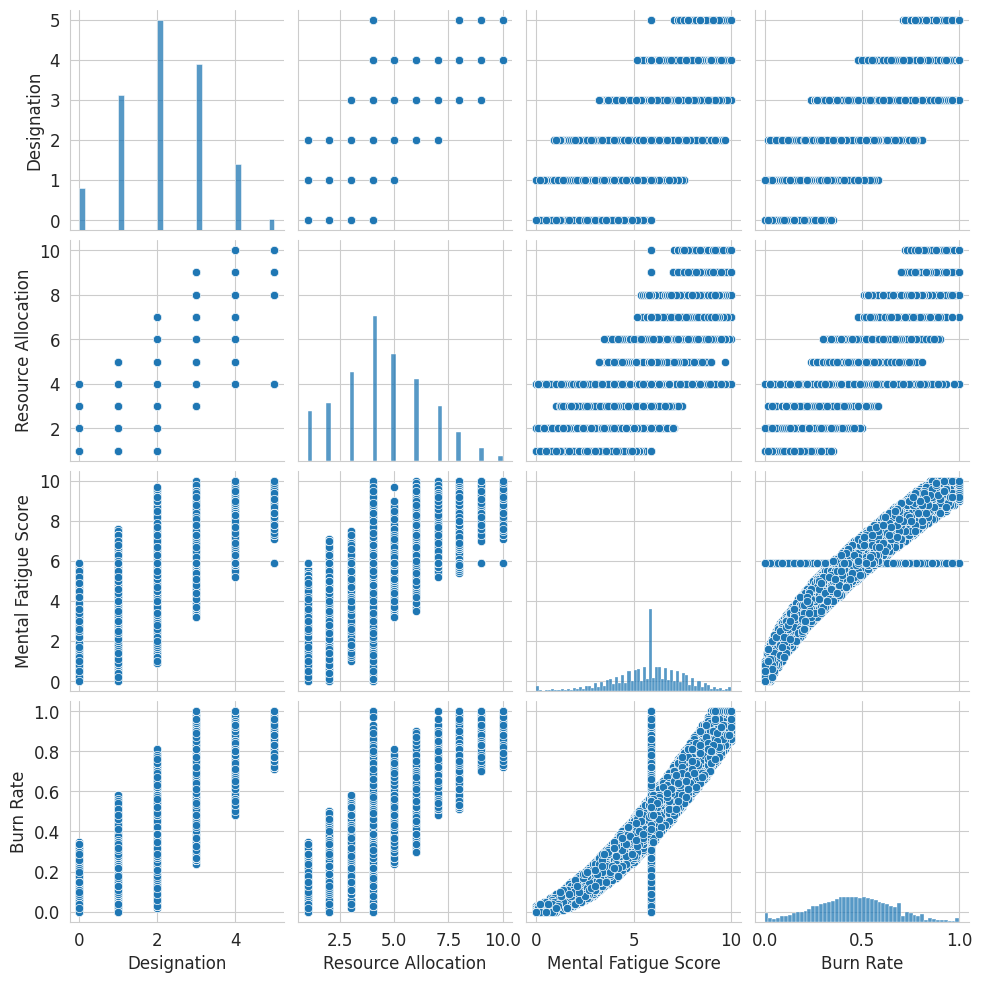

In [60]:
sns.pairplot(
    train[
        [
            "Designation",
            "Resource Allocation",
            "Mental Fatigue Score",
            "Burn Rate"
        ]
    ]
)